In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [28]:
mushrooms = pd.read_csv('/content/mushrooms.csv')
mushrooms.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
X = mushrooms.drop('class', axis=1)
y = mushrooms['class']


In [ ]:
if 'veil-type' in X.columns:
    X = X.drop('veil-type', axis=1)

In [ ]:
X_encoded = pd.get_dummies(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.30, random_state=101)

In [ ]:
dtree = DecisionTreeClassifier(max_depth=3, random_state=101)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=101)

In [ ]:
dtree_pred = dtree.predict(X_test)

print("--- Mushroom Model Evaluation ---")
print("Accuracy Score:", accuracy_score(y_test, dtree_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dtree_pred))
print("\nClassification Report:")
print(classification_report(y_test, dtree_pred))


--- Mushroom Model Evaluation ---
Accuracy Score: 0.9864643150123051

Confusion Matrix:
[[1244   30]
 [   3 1161]]

Classification Report:
              precision    recall  f1-score   support

           e       1.00      0.98      0.99      1274
           p       0.97      1.00      0.99      1164

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



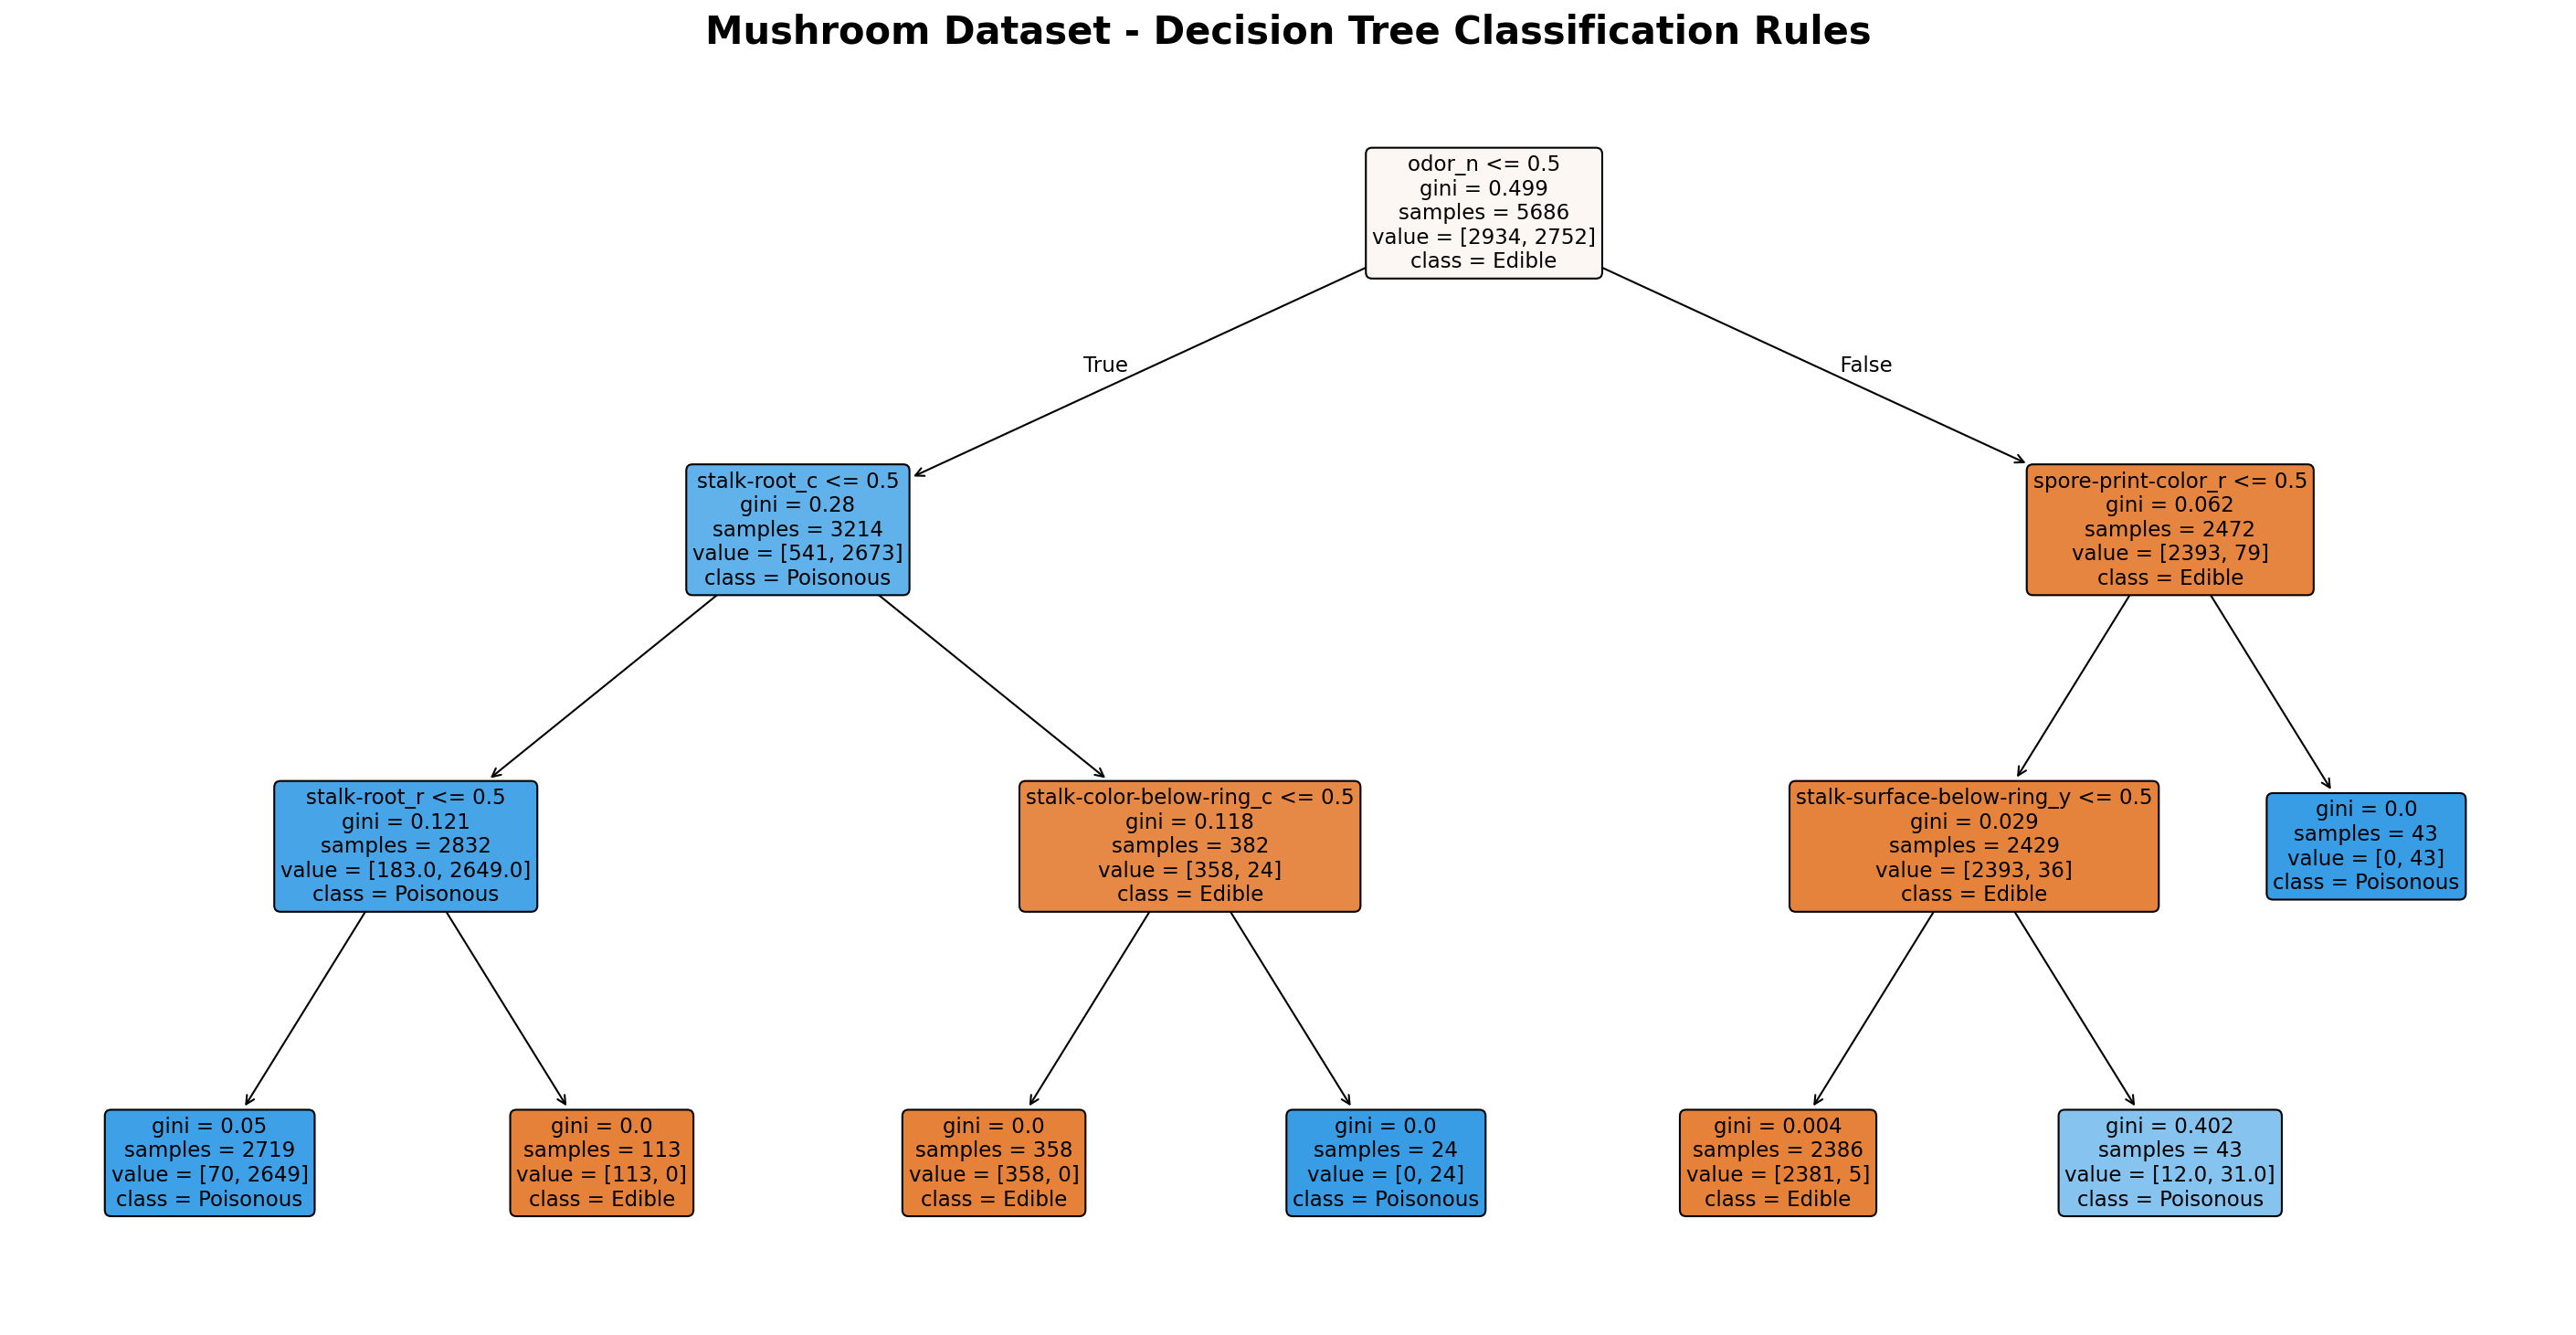

In [ ]:
plt.figure(figsize=(24, 12), dpi=150)

plot_tree(
    dtree,
    feature_names=X_encoded.columns,
    class_names=['Edible', 'Poisonous'],
    filled=True,
    rounded=True,
    fontsize=11
)

plt.title("Mushroom Dataset - Decision Tree Classification Rules", fontsize=20, weight='bold')
plt.show()